## Dataset

- Dataset: House Prices — Advanced Regression Techniques (Kaggle)
- Source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
- Samples: 1460 houses
- Features: 81 columns (including target `SalePrice`)
- Task: Regression (House Price Prediction)


In [147]:
!ls

train.csv


In [148]:
# 데이터 준비
import pandas as pd
df = pd.read_csv("train.csv")

df.head()




,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [149]:
# 1,460개 데이터 , 81개 의 컬럼 (변수)
# 집 샘플(1,460) , 집 정보+ 가격(81),목표값 SalePrice 포함
# 1460 samples
# 81 features

df.shape


(1460, 81)

In [150]:
# X/y분리
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]


In [151]:
# 전처리
X = pd.get_dummies(X)
X = X.fillna(0)


In [152]:
from sklearn.preprocessing import StandardScaler

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [153]:
# split (학습/검증 데이터 분리하기)
from sklearn.model_selection import train_test_split  # 사이킷런 데이터를 나누는 split
# X_train : 집정보(feature), y : 집가격(정답 데이터)

# X_train : 학습용 입력
# y_train : 학습용 정답
# X_val : 검증용 입력
# y_val : 검증용 정답
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,  # 전체 데이터의 20% 를 시험용으로 사용
    random_state=42 # 시드
)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)


(1168, 288)
(292, 288)
(1168,)
(292,)


In [154]:
# bias(절편) 추가
import numpy as np

# bias column 추가
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_val_b   = np.c_[np.ones((X_val.shape[0], 1)), X_val]

print(X_train_b.shape)


(1168, 289)


In [155]:
# Batch Gradient Descent 구현
def batch_gradient_descent(X, y, lr=0.01, epochs=50):

    m, n = X.shape
    w = np.zeros(n)

    losses = []

    for epoch in range(epochs):

        y_pred = X @ w
        error = y_pred - y

        grad = (2/m) * (X.T @ error)
        w -= lr * grad
        # 업데이트 후 loss 다시 계산
        loss = np.mean((X @ w - y)**2)
        losses.append(loss)

    return w, losses


In [156]:
# 실행
w_batch, loss_batch = batch_gradient_descent(
    X_train_b,
    y_train.values,
    lr=0.01,
    epochs=50
)


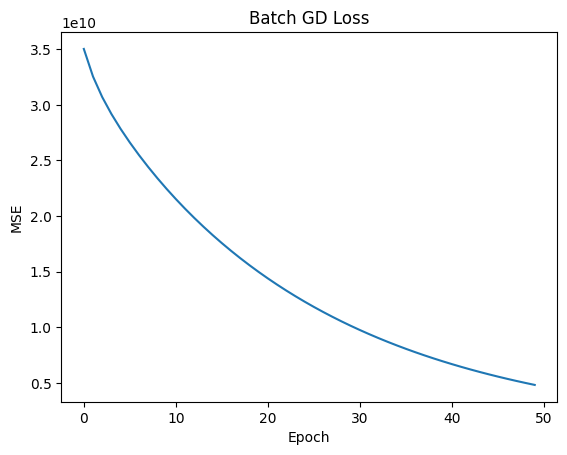

In [157]:
# 학습 확인
import matplotlib.pyplot as plt

plt.plot(loss_batch)
plt.title("Batch GD Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


## 문자열 컬럼을 숫자로 바꾸면 feature 개수가 늘어나는 이유

### ✔ 핵심 개념
- 새 컬럼 개수 = 카테고리 종류 개수
- ML 모델은 숫자만 비교 가능

### ✔ get_dummies 동작
- 컬럼 1개 → 카테고리 개수만큼 컬럼 증가
- feature 수가 증가한다

### ✔ 예시
- 컬럼 종류 50개
→ `pd.get_dummies()` 적용
→ 컬럼도 50개 생성




In [158]:

def stochastic_gradient_descent(X, y, lr=0.01, epochs=10):
  # stochastic_gradient_descent SGD 구현 함수
  #  X : 입력 feature 행렬 (m × n)
  #       m = 데이터 개수(sample 수)
  #       n = feature 개수
  #   y : 실제 정답값 (target, 집 가격)
  #   lr : learning rate (학습률, 얼마나 이동할지)
  #   epochs : 전체 데이터를 몇 번 반복 학습할지


  # m : 데이터 개수 , n : feature 개수
    m, n = X.shape
    # 가중치(weight) feature 개수 만큼 0으로 시작
    w = np.zeros(n)
    # 반복 학습시 마다 loss 를 기록하는 list
    losses = []

    # 전체 데이터 반복학습
    for epoch in range(epochs):
      # SGD 핵심 로직
      # 데이터를 1개 씩 꺼내서 바로 weight(가중치)를 업데이트.
        for i in range(m):
            xi = X[i:i+1] # i 번째 데이터 1개 선택(2차원 형태 유지)
            yi = y[i] # 해당 데이터의 실제 정답값

            # 예측값 계산 (선형회귀 : Xw)
            y_pred = xi @ w
            # 오차 = 예측값 - 실제값
            error = y_pred - yi

            # gradient 게산
            # MSE 의 미분 결과 → * X^T * error
            grad = 2 * xi.T @ error
            # weight 업데이트 (경사하강법)
            w -= lr * grad.flatten()

        # epoch 끝날 때 loss 계산

        # epoch 1회 종료 후 전체 데이터 기준 loss 계산
        loss = np.mean((X @ w - y)**2)
        # loss 기록 (학습진행 확인용)
        losses.append(loss)
    # 최종 weight 와 학습과정 (loss 변화)을 반환
    return w, losses


### Gradient Descent 방식 차이

## Batch Gradient Descent
- 매 epoch마다 전체 데이터(m개)를 모두 사용
- gradient 계산 후 weight 1번 업데이트

예)
m = 1억개라면
→ 1억개 전체를 계산해야
→ weight 업데이트 1번 가능

✔ 안정적이지만 매우 느림


## Stochastic Gradient Descent (SGD)
- 데이터 1개씩 사용
- gradient 계산 후 즉시 업데이트

→ 데이터 1개만 보고 바로 학습 진행
→ 업데이트가 매우 빠름

✔ 빠르지만 방향이 흔들림 (loss 진동 발생)


In [159]:
# SGD 실행 , SGD는 업데이트가 매우 잦아 lr이 크면 발산하기 쉬우므로 작게 설정해야 한다.
w_sgd, loss_sgd = stochastic_gradient_descent(
    X_train_b,
    y_train.values,
    lr=0.0001,
    epochs=20
)


In [160]:
def mini_batch_gradient_descent(X, y, lr=0.01, epochs=20, batch_size=32):

    # Mini-Batch Gradient Descent 구현
    # - batch_size : 한 번에 학습할 데이터 개수


    # m: 샘플 개수, n: feature 개수
    m, n = X.shape

    # 가중치(weight) 0으로 초기화
    w = np.zeros(n)

    # epoch별 loss 기록
    losses = []

    # 전체 데이터 epochs만큼 반복
    for epoch in range(epochs):

        # batch_size 만큼씩 끊어서 학습 (mini-batch)
        for i in range(0, m, batch_size):

            # 미니배치 선택
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # 예측값 계산
            y_pred = X_batch @ w

            # 오차(예측 - 실제)
            error = y_pred - y_batch

            # gradient 계산 (mini-batch 평균)
            grad = (2 / len(X_batch)) * (X_batch.T @ error)

            # weight 업데이트
            w -= lr * grad

        # epoch 종료 후 전체 데이터 기준 loss 계산
        loss = np.mean((X @ w - y)**2)
        losses.append(loss)

    return w, losses


In [161]:
# 실행
w_mb, loss_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train.values,
    lr=0.01,
    epochs=20,
    batch_size=32
)


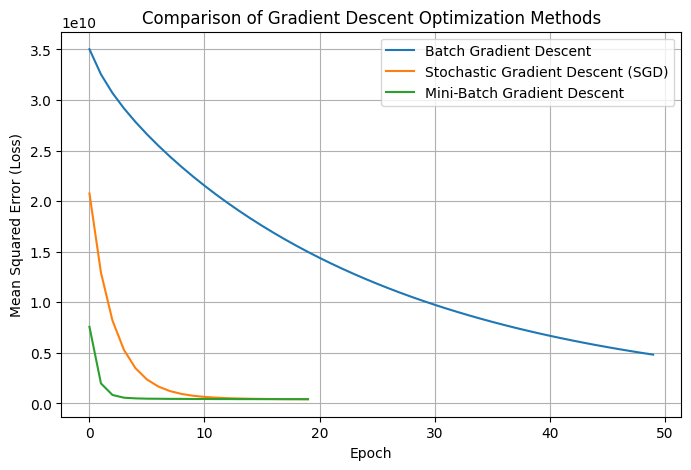

In [162]:
# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent (SGD)")
plt.plot(loss_mb, label="Mini-Batch Gradient Descent")

plt.title("Comparison of Gradient Descent Optimization Methods")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Loss)")
plt.legend()
plt.grid(True)

plt.show()


## Gradient Descent 방식 비교 결과
### ✔ Batch Gradient Descent

Batch Gradient Descent는 전체 데이터의 평균 방향을 기준으로 가중치를 업데이트하기 때문에 학습이 안정적으로 진행된다.
하지만 epoch당 업데이트가 1번만 이루어져 학습 속도가 비교적 느리다.

### ✔ Mini-Batch Gradient Descent

Mini-Batch Gradient Descent는 SGD처럼 업데이트를 자주 수행하면서도 Batch 방식처럼 여러 데이터의 평균 방향을 반영한다.
그 결과 빠른 수렴 속도와 안정적인 학습을 동시에 보이며 세 방법 중 가장 효율적인 학습 양상을 나타냈다.

### ✔ 그래프 관찰

그래프를 확인하면 Batch Gradient Descent보다 Mini-Batch Gradient Descent의 loss가 훨씬 빠르게 감소하는 것을 확인할 수 있다.

### ✔ 왜 이런 차이가 발생할까?

이는 epoch당 업데이트 횟수 차이에서 비롯된다.

- Batch Gradient Descent
→ epoch 1회당 업데이트 1번

- Mini-Batch Gradient Descent
→ epoch 1회당 약 36번 업데이트 (batch_size=32 기준)

즉, 같은 epoch 수라도 실제 학습량(update step)은 서로 다르다.

### ✔ 결론

Gradient Descent 방식 비교를 공정하게 수행하려면
epoch 기준이 아니라 update step 기준으로 비교하는 것이 더 적절하다.
